In [22]:
import matplotlib.pyplot as plt
import polars as pl
import numpy as np

In [23]:
def load_data(file_path, print_info=True):
    data = pl.read_csv(file_path)
    if print_info:
        print(data.glimpse())
    return data


def plot_dos_and_doa(data: pl.DataFrame, window_size=10):
    """
    Plot DoS and DoA metrics with moving average and standard deviation bands.
    
    Args:
        data: Polars DataFrame containing the metrics
        window_size: Window size for moving average calculation
    """
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes = axes.flatten()
    
    # Get the episode and metric columns
    episode = data['# episode'].to_numpy()
    
    # Plot DoS
    if 'dos' in data.columns:
        dos = data['dos'].to_numpy()
        dos_ma = np.convolve(dos, np.ones(window_size)/window_size, mode='valid')
        dos_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        dos_std = np.array([dos[max(0, i-window_size):i].std() for i in range(window_size, len(dos)+1)])
        
        axes[0].plot(dos_episodes, dos_ma, 'b-', linewidth=2, label='Moving Average')
        axes[0].fill_between(dos_episodes, dos_ma - dos_std, dos_ma + dos_std, 
                            alpha=0.3, color='blue', label='±1 Std Dev')
        axes[0].scatter(episode, dos, alpha=0.2, s=10, color='gray', label='Raw Data')
        axes[0].set_xlabel('Episode')
        axes[0].set_ylabel('DoS')
        axes[0].set_title('Degree of Swarming (DoS)')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # Plot DoA
    if 'doa' in data.columns:
        doa = data['doa'].to_numpy()
        doa_ma = np.convolve(doa, np.ones(window_size)/window_size, mode='valid')
        doa_episodes = episode[window_size-1:]
        
        # Calculate rolling standard deviation
        doa_std = np.array([doa[max(0, i-window_size):i].std() for i in range(window_size, len(doa)+1)])
        
        axes[1].plot(doa_episodes, doa_ma, 'r-', linewidth=2, label='Moving Average')
        axes[1].fill_between(doa_episodes, doa_ma - doa_std, doa_ma + doa_std, 
                            alpha=0.3, color='red', label='±1 Std Dev')
        axes[1].scatter(episode, doa, alpha=0.2, s=10, color='gray', label='Raw Data')
        axes[1].set_xlabel('Episode')
        axes[1].set_ylabel('DoA')
        axes[1].set_title('Degree of Alignment (DoA)')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## DDPG

Rows: 201
Columns: 3
$ # episode <f64> 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0
$ dos       <f64> 5.862576, 4.326542, 1.976196, 1.792407, 1.559979, 1.872046, 2.340746, 2.350091, 2.33014, 3.421403
$ doa       <f64> 3.813951, 5.348345, 5.621235, 4.486398, 5.865702, 4.835049, 4.752356, 4.431241, 4.40397, 9.320013

None


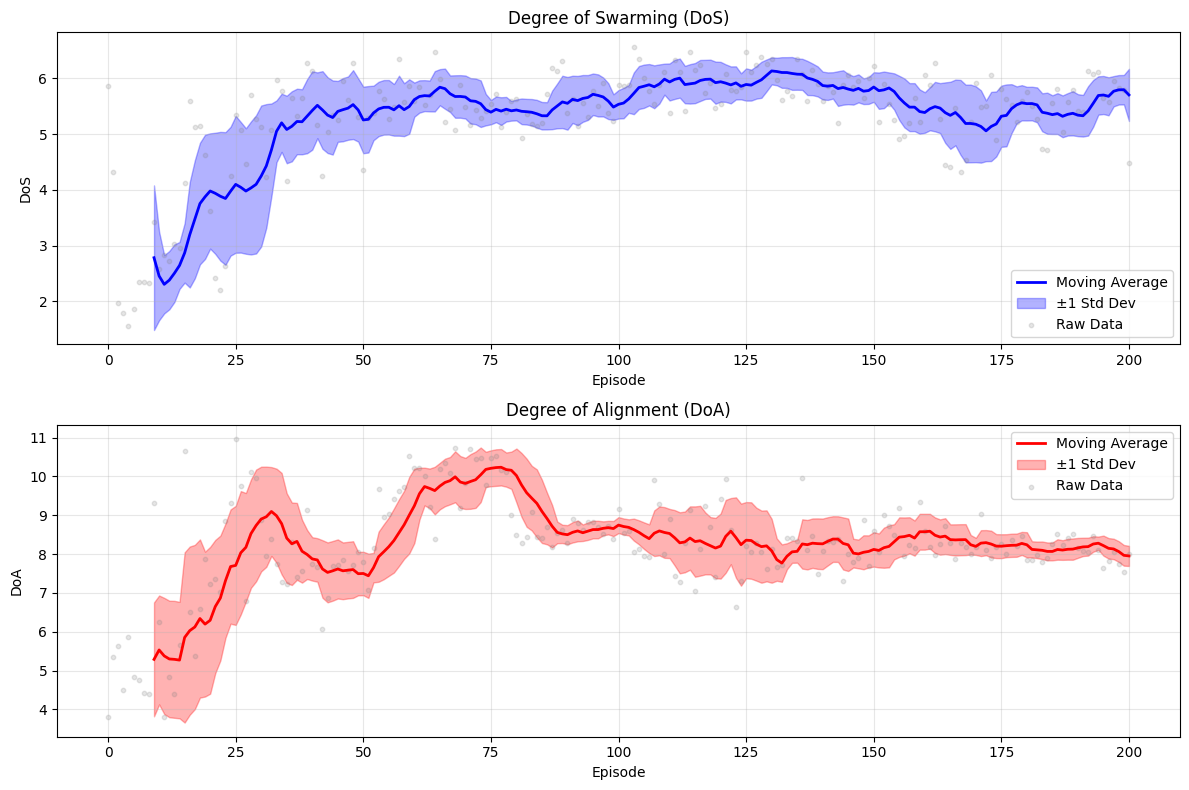

In [24]:
file_path = '../experimental_methods/models/model_1/run33/metrics.csv'

ddpg_data = load_data(file_path)
plot_dos_and_doa(ddpg_data)


## MADDPG

Rows: 201
Columns: 3
$ # episode <f64> 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0
$ dos       <f64> 5.862576, 4.326542, 1.976196, 1.792407, 1.559979, 1.872046, 2.340746, 2.350091, 2.33014, 3.421403
$ doa       <f64> 3.813951, 5.348345, 5.621235, 4.486398, 5.865702, 4.835049, 4.752356, 4.431241, 4.40397, 9.320013

None


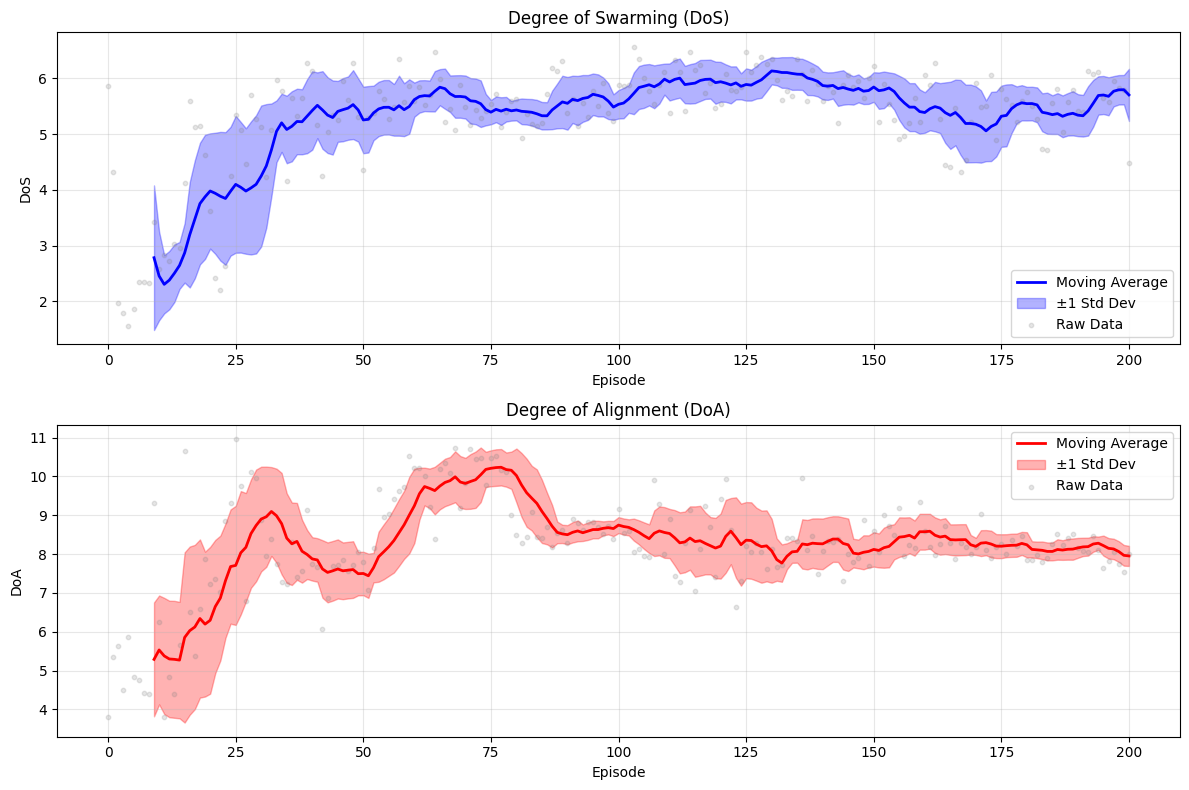

In [25]:
file_path2 = '../experimental_methods/models/maddpg/run3/metrics.csv'

maddpg_data = load_data(file_path2)
plot_dos_and_doa(maddpg_data)

Rows: 201
Columns: 3
$ # episode <f64> 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0
$ dos       <f64> 5.91367, 5.351831, 4.67564, 2.848705, 6.198427, 6.300598, 5.254088, 3.796103, 6.16637, 5.939177
$ doa       <f64> 7.73505, 7.140152, 8.017862, 7.751127, 6.996925, 6.499031, 7.657446, 8.680181, 8.791124, 10.462318

None


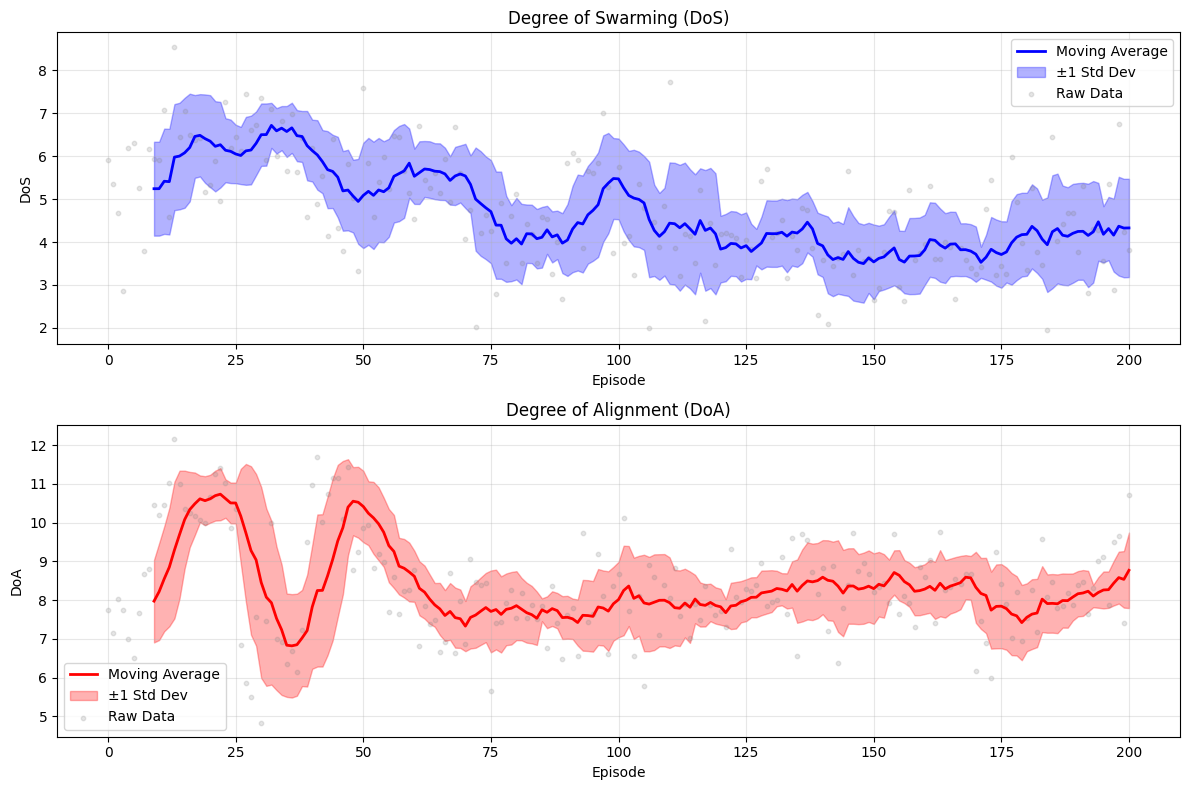

In [26]:
file_path3 = '../experimental_methods/models/maddpg/run6/metrics.csv'

maddpg_data2 = load_data(file_path3)
plot_dos_and_doa(maddpg_data2)